# **Benchmark Final: Comparación Estadística de Modelos de Forecasting**



> ##  Muestreo Provisional
>

In [1]:
from __future__ import annotations

import json
import os
import sys
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

# Resolución robusta de la raíz del repo (notebook puede estar en /notebooks)
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "config" / "config.yaml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

CONFIG = yaml.safe_load((REPO_ROOT / "config" / "config.yaml").read_text(encoding="utf-8"))
SAMPLING = CONFIG.get("sampling", {}) or {}
SAMPLING_ON = bool(SAMPLING.get("enabled", False))

if SAMPLING_ON:
    print("⚠️ MUESTREO PROVISIONAL ACTIVO — los resultados NO son finales.")
    print(f"   n_stations_per_region: {SAMPLING.get('n_stations_per_region')}")
    print(f"   train_years          : {SAMPLING.get('train_years')}")
    print(f"   max_epochs_override  : {SAMPLING.get('max_epochs_override')}")
    print(f"   n_seeds_override     : {SAMPLING.get('n_seeds_override')}")
else:
    print("✅ Configuración completa (sin muestreo). Resultados oficiales.")

✅ Configuración completa (sin muestreo). Resultados oficiales.


## Configuración global, paths e imports

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

from src.utils.regions import (
    all_regions, region_color, region_color_map,
    region_of, stations_by_region,
)
from src.benchmark.stats_tests import (
    diebold_mariano,
    friedman_with_posthoc,
    wilcoxon_pairs,
    ljung_box,
    bds_test,
    bootstrap_ci,
    nemenyi_critical_difference,
    average_ranks,
    shapiro_per_model,
)

EXP_DIR = REPO_ROOT / CONFIG["paths"]["experiments"]
FIG_DIR = REPO_ROOT / CONFIG["paths"]["figures"] / "benchmark_final"
TAB_DIR = REPO_ROOT / CONFIG["paths"]["tables"] / "benchmark_final"
STATS_DIR = REPO_ROOT / CONFIG["paths"]["stats"]
for d in (FIG_DIR, TAB_DIR, STATS_DIR):
    d.mkdir(parents=True, exist_ok=True)

DEFAULT_MODELS = ["persistence", "lstm", "gru", "tcn", "nbeats", "transformer", "tft"]
DEFAULT_HORIZONS = [24, 72, 168]

ALPHA = 0.05            # nivel de significancia declarado
N_BOOT = 1000           # bootstrap percentil
RNG_SEED = 42

sns.set_context("notebook")
sns.set_style("whitegrid")

def show_saved_figure(path: Path | None) -> None:
    if path is None:
        return
    display(Image(filename=str(path)))
    print(path)

## **1. Comparación Tabular**


### 1.1 Carga de resultados desde `experiments/`

In [3]:
def _seed_dirs(model: str) -> list[Path]:
    base = EXP_DIR / model
    if not base.exists():
        return []
    return sorted(p for st in base.iterdir() if st.is_dir()
                  for p in st.iterdir()
                  if p.is_dir() and p.name.startswith("seed="))


def load_predictions_long() -> pd.DataFrame:
    """Devuelve un DataFrame largo: una fila por (modelo, station, seed, horizonte).

    Columnas: model, station, region, seed, horizon, y_true, y_pred (vectores 1D).
    Si no hay runs todavía, devuelve un DataFrame vacío y un mensaje claro.
    """
    rows = []
    target_h = CONFIG["task"]["horizon"]
    for model in DEFAULT_MODELS:
        for sd in _seed_dirs(model):
            station = sd.parent.name
            seed = int(sd.name.split("=", 1)[1])
            try:
                npz = np.load(sd / "predictions.npz", allow_pickle=True)
            except FileNotFoundError:
                continue
            y_true = npz["y_true"]      # (N, H, T)
            y_pred = npz["y_pred"]
            if y_true.ndim == 2:
                y_true = y_true[:, :, None]
                y_pred = y_pred[:, :, None]
            try:
                region = region_of(station)
            except KeyError:
                region = "desconocida"
            for h_step in DEFAULT_HORIZONS:
                # h_step es paso de horizonte (1..target_h). Si target_h<h_step,
                # tomamos el último paso disponible.
                idx = min(h_step, y_true.shape[1]) - 1
                rows.append({
                    "model": model, "station": station, "region": region,
                    "seed": seed, "horizon": h_step,
                    "y_true": y_true[:, idx, 0].astype(float),
                    "y_pred": y_pred[:, idx, 0].astype(float),
                })
    return pd.DataFrame(rows)


try:
    PRED_LONG = load_predictions_long()
except Exception as exc:
    print(f"[load_predictions_long] error: {exc}")
    PRED_LONG = pd.DataFrame()

if PRED_LONG.empty:
    print("Aún no hay resultados. Corre los entrenamientos primero:")
    print("    make train     # o")
    print("    python -m src.training.runner --model lstm --seeds 5  (etc.)")
else:
    print(f"Predicciones cargadas: {len(PRED_LONG)} filas "
          f"(modelo×station×seed×horizonte). Modelos: "
          f"{sorted(PRED_LONG['model'].unique())}.")

Predicciones cargadas: 1155 filas (modelo×station×seed×horizonte). Modelos: ['gru', 'lstm', 'nbeats', 'persistence', 'tcn', 'tft', 'transformer'].


### 1.2 Métricas y bootstrap

Para cada par (modelo, station, seed, horizonte) calculamos RMSE, MAE, R² y
sMAPE sobre el vector de errores `e = y_pred - y_true`, y construimos el IC
95% por **bootstrap percentil** (1000 *resamples*). El bootstrap se realiza
sobre los errores *al cuadrado* para RMSE y sobre los errores *absolutos*
para MAE — así el intervalo refleja la dispersión de la métrica, no de los
errores brutos.

In [4]:
def _rmse(e):  return float(np.sqrt(np.mean(e ** 2)))
def _mae(e):   return float(np.mean(np.abs(e)))
def _smape(yt, yp):
    denom = (np.abs(yt) + np.abs(yp))
    denom[denom == 0] = 1.0
    return float(100 * np.mean(2 * np.abs(yp - yt) / denom))
def _r2(yt, yp):
    ss_res = np.sum((yt - yp) ** 2)
    ss_tot = np.sum((yt - np.mean(yt)) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else float("nan")


def metrics_per_run(df: pd.DataFrame) -> pd.DataFrame:
    """Una fila por (modelo, station, seed, horizonte) con métricas + IC bootstrap."""
    out = []
    if df.empty:
        return pd.DataFrame()
    for _, r in df.iterrows():
        yt, yp = r["y_true"], r["y_pred"]
        e = yp - yt
        ci_rmse = bootstrap_ci(e, n_boot=N_BOOT, alpha=ALPHA,
                               stat_fn=lambda x: float(np.sqrt(np.mean(x ** 2))),
                               seed=RNG_SEED)
        out.append({
            "model": r["model"], "station": r["station"], "region": r["region"],
            "seed": r["seed"], "horizon": r["horizon"],
            "rmse": _rmse(e), "mae": _mae(e),
            "r2": _r2(yt, yp), "smape": _smape(yt, yp),
            "rmse_ci_lo": ci_rmse["lo"], "rmse_ci_hi": ci_rmse["hi"],
        })
    return pd.DataFrame(out)


PER_RUN = metrics_per_run(PRED_LONG) if not PRED_LONG.empty else pd.DataFrame()
PER_RUN.head() if not PER_RUN.empty else "[Aún sin resultados]"

,model,station,region,seed,horizon,rmse,mae,r2,smape,rmse_ci_lo,rmse_ci_hi
0,persistence,A001,Centro-Oeste,42,24,5.018974,3.485432,-0.608893,15.690542,4.628543,5.485484
1,persistence,A001,Centro-Oeste,42,72,5.034158,3.494718,-0.604943,15.722053,4.637145,5.476650
2,persistence,A001,Centro-Oeste,42,168,4.978442,3.485303,-0.563884,15.680705,4.624896,5.398048
3,persistence,A001,Centro-Oeste,43,24,5.018974,3.485432,-0.608893,15.690542,4.628543,5.485484
4,persistence,A001,Centro-Oeste,43,72,5.034158,3.494718,-0.604943,15.722053,4.637145,5.476650


### 1.3 Tabla 1 — por (modelo × horizonte)

In [5]:
def _agg_mean_std(df: pd.DataFrame, by: list[str]) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()
    metrics = ["rmse", "mae", "r2", "smape"]
    g = df.groupby(by)[metrics]
    out = g.agg(["mean", "std"]).round(4)
    out.columns = [f"{m}_{s}" for m, s in out.columns]
    # IC global: media y desviación de los IC por run -> agregamos por bootstrap
    # del propio RMSE entre runs (más informativo que promediar IC individuales)
    def _rmse_mean_ci(x: pd.Series) -> pd.Series:
        ci = bootstrap_ci(x.to_numpy(), n_boot=N_BOOT, alpha=ALPHA,
                          stat_fn=np.mean, seed=RNG_SEED)
        return pd.Series({"rmse_ci_lo": ci["lo"], "rmse_ci_hi": ci["hi"]})

    rmse_ci = df.groupby(by)["rmse"].apply(_rmse_mean_ci).unstack().round(4)
    out = out.join(rmse_ci)
    return out.reset_index()


TBL_MODEL_HOR = _agg_mean_std(PER_RUN, by=["model", "horizon"]) if not PER_RUN.empty else pd.DataFrame()
if not TBL_MODEL_HOR.empty:
    TBL_MODEL_HOR.to_csv(TAB_DIR / "tabla_modelo_x_horizonte.csv", index=False)
TBL_MODEL_HOR

,model,horizon,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std,smape_mean,smape_std,rmse_ci_lo,rmse_ci_hi
0,gru,24,2.4189,1.1125,1.9274,1.0776,0.1608,1.8997,8.8972,5.3080,2.1847,2.6844
1,gru,72,2.9930,1.4374,2.4120,1.3655,-0.5572,3.6836,11.1985,6.9583,2.6778,3.3359
2,gru,168,3.1613,1.6880,2.5778,1.6287,-1.5020,6.8388,11.9511,8.2337,2.8028,3.5563
3,lstm,24,2.4853,1.3224,1.9704,1.2786,0.0279,2.3625,9.1058,6.0559,2.2165,2.7892
4,lstm,72,2.9114,1.4149,2.3235,1.3373,-0.2687,2.9730,10.8631,6.9791,2.6102,3.2355
5,lstm,168,2.9790,1.4222,2.4042,1.3481,-0.6418,4.1006,11.2210,7.1125,2.6718,3.3083
6,nbeats,24,4.0907,2.0378,3.3605,1.7812,-0.8221,3.3608,15.5846,9.6639,3.6016,4.5591
7,nbeats,72,4.1232,2.0223,3.3884,1.7707,-0.9002,3.6726,15.7198,9.6709,3.6395,4.5949
8,nbeats,168,4.1411,2.0698,3.4074,1.7936,-1.1212,4.9254,15.8712,10.0172,3.6543,4.6301
9,persistence,24,5.7387,2.1936,4.0885,1.7927,-2.5250,6.4684,17.8723,8.7019,5.2135,6.2352


### 1.4 Tabla 2 — agregada por modelo (promedio sobre horizontes)

In [6]:
TBL_MODEL = _agg_mean_std(PER_RUN, by=["model"]) if not PER_RUN.empty else pd.DataFrame()
if not TBL_MODEL.empty:
    TBL_MODEL = TBL_MODEL.sort_values("rmse_mean")
    TBL_MODEL.to_csv(TAB_DIR / "tabla_modelo_agg.csv", index=False)
TBL_MODEL

,model,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std,smape_mean,smape_std,rmse_ci_lo,rmse_ci_hi
6,transformer,2.3553,1.1189,1.8138,0.9067,0.4170,0.3824,7.9266,4.7259,2.0381,2.6601
4,tcn,2.4943,1.2768,1.9566,1.0572,-0.0945,3.0077,9.2284,6.0015,2.3224,2.6645
1,lstm,2.7919,1.3980,2.2327,1.3290,-0.2942,3.2215,10.3966,6.7646,2.6117,2.9653
0,gru,2.8578,1.4606,2.3057,1.3970,-0.6328,4.6431,10.6823,7.0269,2.6602,3.0455
5,tft,3.8462,0.6073,3.1404,0.4603,0.1605,0.2178,14.8584,3.9842,3.5967,4.0860
2,nbeats,4.1183,2.0340,3.3854,1.7737,-0.9478,4.0240,15.7252,9.7405,3.8482,4.3807
3,persistence,5.7184,2.1750,4.0847,1.7798,-2.6350,7.0073,17.8560,8.6353,5.4188,6.0027


### 1.5 Tabla 3 — por (modelo × región)

In [7]:
TBL_REGION = _agg_mean_std(PER_RUN, by=["model", "region"]) if not PER_RUN.empty else pd.DataFrame()
if not TBL_REGION.empty:
    TBL_REGION.to_csv(TAB_DIR / "tabla_modelo_x_region.csv", index=False)
TBL_REGION

,model,region,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std,smape_mean,smape_std,rmse_ci_lo,rmse_ci_hi
0,gru,Centro-Oeste,3.6018,1.4346,2.9574,1.6209,0.6259,0.1225,11.3760,4.6077,3.1555,4.0678
1,gru,Nordeste,2.1223,0.9902,1.8604,1.0144,-5.8304,9.8460,6.8431,3.5007,1.8443,2.4017
2,gru,Norte,1.8996,0.9468,1.4265,0.7193,0.4841,0.2719,5.1492,2.4572,1.6207,2.1930
3,gru,Sudeste,2.6713,0.5404,2.0467,0.4365,0.5919,0.2110,9.6116,2.3843,2.5270,2.8021
4,gru,Sul,4.1534,1.8521,3.4048,1.8723,-0.3514,2.7664,20.8365,7.8196,3.6360,4.7965
5,lstm,Centro-Oeste,3.4989,1.2656,2.8682,1.4421,0.6361,0.1134,11.0469,3.9794,3.0882,3.8950
6,lstm,Nordeste,1.7749,0.6448,1.5016,0.6443,-3.6354,6.7484,5.6397,2.4160,1.5822,1.9667
7,lstm,Norte,1.9249,0.9117,1.4318,0.6823,0.4769,0.2238,5.1820,2.3910,1.6392,2.1981
8,lstm,Sudeste,2.7154,0.5426,2.0748,0.4296,0.5683,0.2430,9.7220,2.2962,2.5668,2.8499
9,lstm,Sul,4.1683,1.7427,3.4228,1.8233,-0.3419,2.3876,20.6781,6.9122,3.6711,4.7390


### 1.6 Visualización — barras con error bars + heatmap

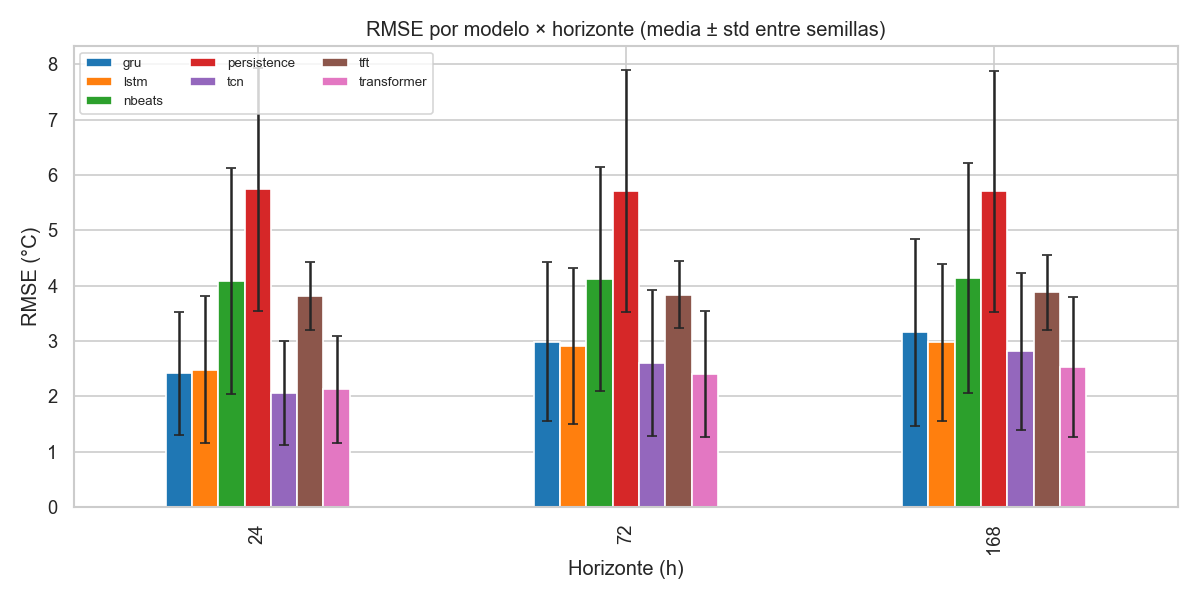

C:\Users\sergi\Proyecto-final-Deep-learning\results\figures\benchmark_final\01_rmse_modelo_x_horizonte.png


In [8]:
def plot_rmse_bars(tbl: pd.DataFrame) -> Path | None:
    if tbl.empty:
        print("Tabla vacía — corre el benchmark."); return None
    fig, ax = plt.subplots(figsize=(10, 5))
    pivot = tbl.pivot(index="horizon", columns="model", values="rmse_mean")
    err = tbl.pivot(index="horizon", columns="model", values="rmse_std")
    pivot.plot(kind="bar", yerr=err, ax=ax, capsize=3)
    ax.set_ylabel("RMSE (°C)"); ax.set_xlabel("Horizonte (h)")
    ax.set_title("RMSE por modelo × horizonte (media ± std entre semillas)")
    ax.legend(loc="upper left", ncol=3, fontsize=8)
    plt.tight_layout()
    out = FIG_DIR / "01_rmse_modelo_x_horizonte.png"
    fig.savefig(out, dpi=120); plt.close(fig)
    return out


show_saved_figure(plot_rmse_bars(TBL_MODEL_HOR))

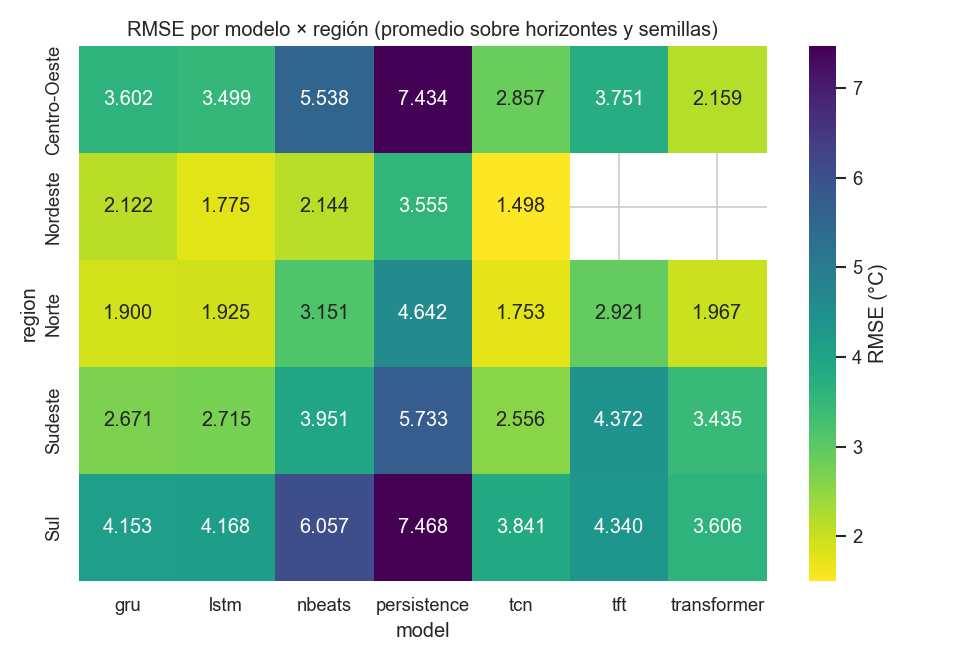

C:\Users\sergi\Proyecto-final-Deep-learning\results\figures\benchmark_final\02_heatmap_modelo_x_region.png


In [9]:
def plot_heatmap_region(tbl: pd.DataFrame) -> Path | None:
    if tbl.empty:
        print("Tabla vacía."); return None
    pivot = tbl.pivot(index="region", columns="model", values="rmse_mean")
    if pivot.empty:
        return None
    fig, ax = plt.subplots(figsize=(8, 4 + 0.3 * len(pivot.index)))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis_r", ax=ax,
                cbar_kws={"label": "RMSE (°C)"})
    ax.set_title("RMSE por modelo × región (promedio sobre horizontes y semillas)")
    plt.tight_layout()
    out = FIG_DIR / "02_heatmap_modelo_x_region.png"
    fig.savefig(out, dpi=120); plt.close(fig)
    return out


show_saved_figure(plot_heatmap_region(TBL_REGION))

## **2. Ranking de Modelos**


### 2.1 Ranking principal

In [10]:
def _emoji(rank: int) -> str:
    return {1: "🥇", 2: "🥈", 3: "🥉"}.get(rank, "  ")


def ranking_table(tbl_model: pd.DataFrame) -> pd.DataFrame:
    if tbl_model.empty:
        return pd.DataFrame()
    df = tbl_model.copy().sort_values("rmse_mean").reset_index(drop=True)
    df["rank"] = df.index + 1
    df["medal"] = df["rank"].map(_emoji)
    cols = ["medal", "rank", "model", "rmse_mean", "rmse_std",
            "rmse_ci_lo", "rmse_ci_hi", "mae_mean", "r2_mean", "smape_mean"]
    return df[cols]


RANK = ranking_table(TBL_MODEL) if not TBL_MODEL.empty else pd.DataFrame()
if not RANK.empty:
    RANK.to_csv(TAB_DIR / "ranking_global.csv", index=False)
RANK

,medal,rank,model,rmse_mean,rmse_std,rmse_ci_lo,rmse_ci_hi,mae_mean,r2_mean,smape_mean
0,🥇,1,transformer,2.3553,1.1189,2.0381,2.6601,1.8138,0.4170,7.9266
1,🥈,2,tcn,2.4943,1.2768,2.3224,2.6645,1.9566,-0.0945,9.2284
2,🥉,3,lstm,2.7919,1.3980,2.6117,2.9653,2.2327,-0.2942,10.3966
3,,4,gru,2.8578,1.4606,2.6602,3.0455,2.3057,-0.6328,10.6823
4,,5,tft,3.8462,0.6073,3.5967,4.0860,3.1404,0.1605,14.8584
5,,6,nbeats,4.1183,2.0340,3.8482,4.3807,3.3854,-0.9478,15.7252
6,,7,persistence,5.7184,2.1750,5.4188,6.0027,4.0847,-2.6350,17.8560


### 2.2 Ranking por horizonte (detecta inversiones)

In [11]:
def ranking_by_horizon(tbl: pd.DataFrame) -> pd.DataFrame:
    if tbl.empty: return pd.DataFrame()
    rows = []
    for h, grp in tbl.groupby("horizon"):
        sub = grp.sort_values("rmse_mean").reset_index(drop=True)
        sub["rank"] = sub.index + 1
        rows.append(sub)
    return pd.concat(rows, ignore_index=True)


RANK_BY_HOR = ranking_by_horizon(TBL_MODEL_HOR) if not TBL_MODEL_HOR.empty else pd.DataFrame()
if not RANK_BY_HOR.empty:
    RANK_BY_HOR.to_csv(TAB_DIR / "ranking_por_horizonte.csv", index=False)
RANK_BY_HOR.pivot(index="model", columns="horizon", values="rank") if not RANK_BY_HOR.empty else "[sin datos]"

horizon,24,72,168
model,,,
gru,3,4,4
lstm,4,3,3
nbeats,6,6,6
persistence,7,7,7
tcn,1,2,2
tft,5,5,5
transformer,2,1,1


### 2.3 Análisis trade-off — scatter RMSE × costo y frontera de Pareto

In [12]:
def collect_runtime_and_params() -> pd.DataFrame:
    """Lee history.json y env.json de cada run para tiempo de entrenamiento
    y número de parámetros (si está expuesto)."""
    rows = []
    for model in DEFAULT_MODELS:
        for sd in _seed_dirs(model):
            hist_path = sd / "history.json"
            if not hist_path.exists():
                continue
            try:
                hist = json.loads(hist_path.read_text(encoding="utf-8"))
            except Exception:
                continue
            train_min = float(hist.get("train_minutes", float("nan")))
            n_params = float(hist.get("n_parameters", float("nan")))
            rows.append({"model": model, "train_min": train_min,
                         "n_params": n_params})
    return pd.DataFrame(rows)


COSTS = collect_runtime_and_params()
COSTS_AGG = COSTS.groupby("model")[["train_min", "n_params"]].mean() if not COSTS.empty else pd.DataFrame()
COSTS_AGG

,train_min,n_params
model,,
gru,NaN,NaN
lstm,NaN,NaN
nbeats,NaN,NaN
persistence,NaN,NaN
tcn,NaN,NaN
tft,NaN,NaN
transformer,NaN,NaN


In [13]:
def plot_pareto(tbl_model: pd.DataFrame, costs_agg: pd.DataFrame) -> Path | None:
    if tbl_model.empty or costs_agg.empty:
        print("Insuficientes datos para Pareto."); return None
    df = tbl_model.set_index("model").join(costs_agg, how="inner").dropna(subset=["train_min"])
    if df.empty:
        print("Sin tiempos registrados — re-corre con timing en history.json"); return None
    df = df.reset_index()
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(df["train_min"], df["rmse_mean"], s=80)
    for _, r in df.iterrows():
        ax.annotate(r["model"], (r["train_min"], r["rmse_mean"]),
                    textcoords="offset points", xytext=(6, 4))
    # Frontera de Pareto: minimizar (train_min, rmse_mean)
    sorted_df = df.sort_values("train_min")
    pareto, best_rmse = [], float("inf")
    for _, r in sorted_df.iterrows():
        if r["rmse_mean"] < best_rmse:
            pareto.append((r["train_min"], r["rmse_mean"]))
            best_rmse = r["rmse_mean"]
    if pareto:
        xs, ys = zip(*pareto)
        ax.plot(xs, ys, "r--", alpha=0.6, label="Frontera de Pareto")
        ax.legend()
    ax.set_xscale("log")
    ax.set_xlabel("Tiempo de entrenamiento por run (min, log)")
    ax.set_ylabel("RMSE medio (°C)")
    ax.set_title("Trade-off precisión vs costo computacional")
    plt.tight_layout()
    out = FIG_DIR / "03_pareto_rmse_vs_cost.png"
    fig.savefig(out, dpi=120); plt.close(fig)
    return out


show_saved_figure(plot_pareto(TBL_MODEL, COSTS_AGG))

Sin tiempos registrados — re-corre con timing en history.json


## **3. Análisis Estadístico y Pruebas de Hipótesis**


**Convenciones declaradas.**

- Nivel de significancia: $\alpha = 0.05$.
- Reportamos **p-valores exactos** (no solo `<0.05`).
- Verificamos los supuestos de cada test antes de interpretar.
- IC 95% por bootstrap percentil (n_boot = 1000).
- Tamaño muestral: en el pipeline completo, **5 semillas × 40 estaciones**
  por modelo (n=200 puntos pareados). En *muestreo provisional*, **2×5 = 10**
  puntos 

### 3.1 Verificación de supuestos — Shapiro-Wilk

In [14]:
def errors_panel_per_seed(df: pd.DataFrame) -> pd.DataFrame:
    """Panel: filas = (station, seed, horizon), columnas = modelo, valor = RMSE."""
    if df.empty: return pd.DataFrame()
    return (df.pivot_table(index=["station", "seed", "horizon"],
                            columns="model", values="rmse").dropna(axis=0, how="any"))


def panel_for_scikit_posthocs(panel: pd.DataFrame) -> pd.DataFrame:
    if panel.empty:
        return pd.DataFrame()
    out = panel.reset_index(drop=True).copy()
    out.columns.name = None
    out.index.name = "dataset"
    return out


ERR_PANEL = errors_panel_per_seed(PER_RUN)
ERR_PANEL_FRIEDMAN = panel_for_scikit_posthocs(ERR_PANEL)
if not ERR_PANEL.empty:
    SHAPIRO = shapiro_per_model(ERR_PANEL, alpha=ALPHA)
    SHAPIRO.to_csv(TAB_DIR / "shapiro_por_modelo.csv", index=False)
else:
    SHAPIRO = pd.DataFrame()
SHAPIRO

,model,stat,p_value,normal
0,gru,0.863115,0.003867,False
1,lstm,0.843820,0.001682,False
2,nbeats,0.900827,0.022411,False
3,persistence,0.842587,0.001597,False
4,tcn,0.842724,0.001607,False
5,tft,0.837640,0.001300,False
6,transformer,0.853060,0.002493,False


Si **algún modelo rechaza normalidad** (`p_value < 0.05`), priorizamos tests
**no paramétricos** (Wilcoxon, Friedman + Nemenyi) sobre los paramétricos
(t-test pareado, ANOVA). En forecasting es lo habitual: la distribución de
RMSE entre semillas suele ser sesgada por *outliers* (semillas que cayeron en
malos mínimos locales).

### 3.2 Wilcoxon signed-rank — comparaciones pareadas

In [15]:
def wilcoxon_matrix(panel: pd.DataFrame) -> pd.DataFrame:
    if panel.empty: return pd.DataFrame()
    pairs = wilcoxon_pairs(panel, alpha=ALPHA)
    models = list(panel.columns)
    M = pd.DataFrame(np.nan, index=models, columns=models)
    for k, v in pairs.items():
        a, _, b = k.partition(" vs ")
        if "pvalue" in v:
            M.loc[a, b] = v["pvalue"]
            M.loc[b, a] = v["pvalue"]
    np.fill_diagonal(M.values, 1.0)
    return M


WILC_M = wilcoxon_matrix(ERR_PANEL)
if not WILC_M.empty:
    WILC_M.to_csv(TAB_DIR / "wilcoxon_pvalues.csv")
WILC_M

,gru,lstm,nbeats,persistence,tcn,tft,transformer
gru,1.000000e+00,1.208402e-01,1.192093e-07,1.192093e-07,5.328655e-05,1.192093e-07,7.629395e-05
lstm,1.208402e-01,1.000000e+00,1.192093e-07,1.192093e-07,3.576279e-07,1.192093e-07,1.754761e-04
nbeats,1.192093e-07,1.192093e-07,1.000000e+00,1.192093e-07,1.192093e-07,5.270591e-01,1.192093e-07
persistence,1.192093e-07,1.192093e-07,1.192093e-07,1.000000e+00,1.192093e-07,1.192093e-07,1.192093e-07
tcn,5.328655e-05,3.576279e-07,1.192093e-07,1.192093e-07,1.000000e+00,1.192093e-07,1.192093e-07
tft,1.192093e-07,1.192093e-07,5.270591e-01,1.192093e-07,1.192093e-07,1.000000e+00,1.192093e-07
transformer,7.629395e-05,1.754761e-04,1.192093e-07,1.192093e-07,1.192093e-07,1.192093e-07,1.000000e+00


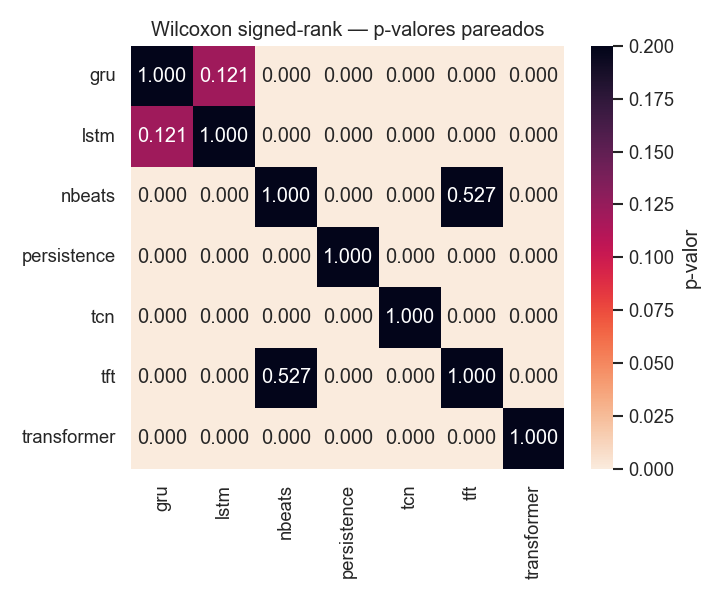

C:\Users\sergi\Proyecto-final-Deep-learning\results\figures\benchmark_final\04_wilcoxon_heatmap.png


In [16]:
def plot_pvalue_heatmap(M: pd.DataFrame, title: str, fname: str) -> Path | None:
    if M.empty: return None
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(M, annot=True, fmt=".3f", cmap="rocket_r",
                vmin=0, vmax=0.2, cbar_kws={"label": "p-valor"}, ax=ax)
    ax.set_title(title)
    plt.tight_layout()
    out = FIG_DIR / fname
    fig.savefig(out, dpi=120); plt.close(fig)
    return out


show_saved_figure(plot_pvalue_heatmap(WILC_M, "Wilcoxon signed-rank — p-valores pareados",
                                      "04_wilcoxon_heatmap.png"))

### 3.3 Friedman + post-hoc (Nemenyi / Bonferroni / Holm)

In [17]:
ERR_PANEL_FRIEDMAN = ERR_PANEL.reset_index(drop=True).copy() if not ERR_PANEL.empty else pd.DataFrame()
if not ERR_PANEL_FRIEDMAN.empty:
    ERR_PANEL_FRIEDMAN.columns.name = None
    ERR_PANEL_FRIEDMAN.index.name = "dataset"

FRIED = friedman_with_posthoc(ERR_PANEL_FRIEDMAN, posthoc="nemenyi") if not ERR_PANEL_FRIEDMAN.empty else {}
if FRIED:
    (STATS_DIR / "friedman_final.json").write_text(
        json.dumps(FRIED, indent=2, default=str), encoding="utf-8")
print(json.dumps({k: v for k, v in FRIED.items() if k != "posthoc"}, indent=2, default=str))

{
  "friedman": {
    "stat": 133.80357142857144,
    "pvalue": 2.031188430138598e-26,
    "n_datasets": 24,
    "n_models": 7
  }
}


In [18]:
# Repetir con Bonferroni y Holm para comparar correcciones
if "ERR_PANEL_FRIEDMAN" not in globals():
    ERR_PANEL_FRIEDMAN = ERR_PANEL.reset_index(drop=True).copy() if not ERR_PANEL.empty else pd.DataFrame()
    if not ERR_PANEL_FRIEDMAN.empty:
        ERR_PANEL_FRIEDMAN.columns.name = None
        ERR_PANEL_FRIEDMAN.index.name = "dataset"

FRIED_BONF = friedman_with_posthoc(ERR_PANEL_FRIEDMAN, posthoc="bonferroni") if not ERR_PANEL_FRIEDMAN.empty else {}
FRIED_HOLM = friedman_with_posthoc(ERR_PANEL_FRIEDMAN, posthoc="holm") if not ERR_PANEL_FRIEDMAN.empty else {}

def _ph_to_df(d: dict) -> pd.DataFrame:
    if not d or "posthoc" not in d: return pd.DataFrame()
    return pd.DataFrame(d["posthoc"]["pvalues"])


PH_NEMENYI = _ph_to_df(FRIED)
PH_BONF = _ph_to_df(FRIED_BONF)
PH_HOLM = _ph_to_df(FRIED_HOLM)
PH_NEMENYI

,gru,lstm,nbeats,persistence,tcn,tft,transformer
gru,1.000000e+00,9.848702e-01,1.580138e-05,5.454526e-13,6.359760e-01,8.939292e-07,0.169424
lstm,9.848702e-01,1.000000e+00,6.808450e-04,1.976705e-10,1.694237e-01,5.963946e-05,0.635976
nbeats,1.580138e-05,6.808450e-04,1.000000e+00,1.052182e-01,7.813732e-10,9.983408e-01,0.169424
persistence,5.454526e-13,1.976705e-10,1.052182e-01,1.000000e+00,0.000000e+00,3.301077e-01,0.000006
tcn,6.359760e-01,1.694237e-01,7.813732e-10,0.000000e+00,1.000000e+00,1.832223e-11,0.000681
tft,8.939292e-07,5.963946e-05,9.983408e-01,3.301077e-01,1.832223e-11,1.000000e+00,0.042173
transformer,1.694237e-01,6.359760e-01,1.694237e-01,5.565048e-06,6.808450e-04,4.217266e-02,1.000000


### 3.4 Diagrama de Distancia Crítica (CD) — Nemenyi

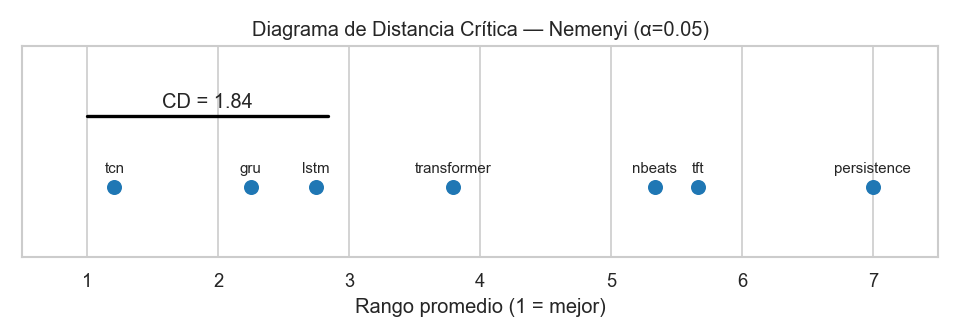

C:\Users\sergi\Proyecto-final-Deep-learning\results\figures\benchmark_final\05_cd_diagram_nemenyi.png


In [19]:
def plot_cd_diagram(panel: pd.DataFrame, alpha: float = 0.05) -> Path | None:
    if panel.empty: return None
    n_models = panel.shape[1]; n_datasets = panel.shape[0]
    cd = nemenyi_critical_difference(n_models, n_datasets, alpha=alpha)
    ranks = average_ranks(panel)
    fig, ax = plt.subplots(figsize=(8, 2.8))
    ax.set_xlim(0.5, n_models + 0.5); ax.set_ylim(0, 3)
    ax.plot(ranks.values, [1] * n_models, "o", markersize=8)
    for m, r in ranks.items():
        ax.annotate(m, (r, 1), textcoords="offset points", xytext=(0, 8),
                    ha="center", fontsize=9)
    ax.plot([1, 1 + cd], [2, 2], "k-", lw=2)
    ax.annotate(f"CD = {cd:.2f}", (1 + cd / 2, 2), xytext=(0, 5),
                textcoords="offset points", ha="center")
    ax.set_yticks([]); ax.set_xlabel("Rango promedio (1 = mejor)")
    ax.set_title(f"Diagrama de Distancia Crítica — Nemenyi (α={alpha})")
    plt.tight_layout()
    out = FIG_DIR / "05_cd_diagram_nemenyi.png"
    fig.savefig(out, dpi=120); plt.close(fig)
    return out


show_saved_figure(plot_cd_diagram(ERR_PANEL, alpha=ALPHA))

### 3.5 Diebold-Mariano (HLN-corrected) por pares

In [20]:
def diebold_mariano_matrix() -> pd.DataFrame:
    """Matriz simétrica de p-valores DM (HLN) entre pares de modelos.

    Para cada par (m1, m2), promedia los p-valores sobre runs pareados
    (misma station, mismo seed, mismo horizonte).
    """
    if PRED_LONG.empty: return pd.DataFrame()
    cfg_dm = CONFIG["stats"]["diebold_mariano"]
    p_table: dict[tuple[str, str], list[float]] = {}
    keyed = PRED_LONG.set_index(["model", "station", "seed", "horizon"])
    keys = keyed.index.unique()
    by_run = {(s, sd, h): {} for (_, s, sd, h) in keys}
    for (m, s, sd, h), row in keyed.iterrows():
        by_run.setdefault((s, sd, h), {})[m] = row["y_pred"] - row["y_true"]

    for run_key, errs in by_run.items():
        for m1, m2 in combinations(sorted(errs), 2):
            try:
                res = diebold_mariano(errs[m1], errs[m2],
                                      h=cfg_dm["h"], power=cfg_dm["power"],
                                      alternative=cfg_dm["alternative"])
                p_table.setdefault((m1, m2), []).append(res["pvalue"])
            except (AssertionError, ValueError):
                continue
    models = sorted({m for pair in p_table for m in pair})
    M = pd.DataFrame(np.nan, index=models, columns=models)
    for (m1, m2), vals in p_table.items():
        v = float(np.nanmedian(vals))
        M.loc[m1, m2] = v; M.loc[m2, m1] = v
    np.fill_diagonal(M.values, 1.0)
    return M


DM_M = diebold_mariano_matrix() if not PRED_LONG.empty else pd.DataFrame()
if not DM_M.empty:
    DM_M.to_csv(TAB_DIR / "diebold_mariano_pvalues.csv")
DM_M

,gru,lstm,nbeats,persistence,tcn,tft,transformer
gru,1.0,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0
lstm,0.0,1.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0
nbeats,0.0,0.0,1.000000e+00,2.471935e-09,0.0,0.000000e+00,0.0
persistence,0.0,0.0,2.471935e-09,1.000000e+00,0.0,1.568134e-07,0.0
tcn,0.0,0.0,0.000000e+00,0.000000e+00,1.0,0.000000e+00,0.0
tft,0.0,0.0,0.000000e+00,1.568134e-07,0.0,1.000000e+00,0.0
transformer,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,1.0


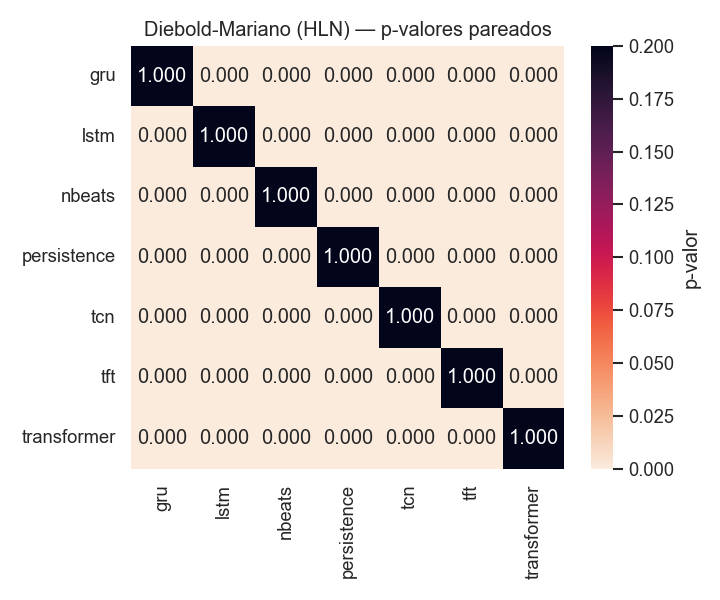

C:\Users\sergi\Proyecto-final-Deep-learning\results\figures\benchmark_final\06_dm_heatmap.png


In [21]:
show_saved_figure(plot_pvalue_heatmap(DM_M, "Diebold-Mariano (HLN) — p-valores pareados",
                                      "06_dm_heatmap.png"))

### 3.6 Diagnóstico de residuos — Ljung-Box y BDS

In [22]:
def residuals_per_model(df: pd.DataFrame) -> dict[str, np.ndarray]:
    if df.empty: return {}
    out = {}
    for m, grp in df.groupby("model"):
        all_e = np.concatenate([(r["y_pred"] - r["y_true"]).ravel()
                                for _, r in grp.iterrows()])
        out[m] = all_e
    return out


BDS_MAX_N = 500


def bds_test_limited(residuals: np.ndarray, *, max_n: int = BDS_MAX_N,
                     seed: int = RNG_SEED) -> dict:
    values = np.asarray(residuals, dtype=float).ravel()
    values = values[np.isfinite(values)]
    n_total = len(values)
    if n_total > max_n:
        rng = np.random.default_rng(seed)
        idx = np.sort(rng.choice(n_total, size=max_n, replace=False))
        values = values[idx]
    try:
        out = bds_test(values)
    except MemoryError:
        out = {"skipped": "BDS omitido por memoria; reduce BDS_MAX_N"}
    out["bds_n_used"] = int(len(values))
    out["bds_n_total"] = int(n_total)
    if n_total > len(values) and "skipped" not in out:
        out["note"] = (f"BDS calculado sobre muestra determinística de "
                       f"{len(values)} de {n_total} residuos para evitar memoria O(n^2).")
    return out


RESIDS = residuals_per_model(PRED_LONG)
diag_rows = []
for m, e in RESIDS.items():
    if len(e) < 200: continue
    lb_24 = ljung_box(e, lags=24)
    lb_168 = ljung_box(e, lags=168)
    bds = bds_test_limited(e)
    diag_rows.append({
        "model": m,
        "ljung_box_lag24_p": lb_24["pvalue"],
        "ljung_box_lag168_p": lb_168["pvalue"],
        "bds_p_min": (min(bds["pvalue"]) if "pvalue" in bds else float("nan")),
        "bds_n_used": bds.get("bds_n_used", len(e)),
        "bds_n_total": bds.get("bds_n_total", len(e)),
        "bds_note": bds.get("note", bds.get("skipped", "")),
    })
RESID_DIAG = pd.DataFrame(diag_rows)
if not RESID_DIAG.empty:
    RESID_DIAG.to_csv(TAB_DIR / "residual_diagnostics.csv", index=False)
RESID_DIAG

,model,ljung_box_lag24_p,ljung_box_lag168_p,bds_p_min,bds_n_used,bds_n_total,bds_note
0,gru,0.0,0.0,1.323291e-20,500,1819800,BDS calculado sobre muestra determinística de ...
1,lstm,0.0,0.0,1.333452e-15,500,1819800,BDS calculado sobre muestra determinística de ...
2,nbeats,0.0,0.0,1.069034e-20,500,1819800,BDS calculado sobre muestra determinística de ...
3,persistence,0.0,0.0,1.043259e-10,500,1819800,BDS calculado sobre muestra determinística de ...
4,tcn,0.0,0.0,8.325412e-08,500,1819800,BDS calculado sobre muestra determinística de ...
5,tft,0.0,0.0,2.708425e-01,500,202200,BDS calculado sobre muestra determinística de ...
6,transformer,0.0,0.0,2.122869e-28,500,429675,BDS calculado sobre muestra determinística de ...


In [23]:
# Advertencia operativa sobre el número de semillas
n_seeds_eff = SAMPLING.get("n_seeds_override", CONFIG["project"]["seeds_per_model"]) if SAMPLING_ON               else CONFIG["project"]["seeds_per_model"]
if n_seeds_eff < 3:
    print(f"⚠️ Solo {n_seeds_eff} semillas por modelo. Algunos tests "
          "(Wilcoxon, Friedman) pierden potencia. Resultados solo de validación.")
else:
    print(f"OK — {n_seeds_eff} semillas por modelo (mínimo del PDF: 3).")

⚠️ Solo 2 semillas por modelo. Algunos tests (Wilcoxon, Friedman) pierden potencia. Resultados solo de validación.


## **4. Análisis Cualitativo**

Las métricas agregan errores; este apartado **abre la caja**. Examinamos:

1. **Predicción vs ground truth** en una ventana de 7 días por región.
2. **Errores sistemáticos** por hora del día y por mes (estacionalidad).
3. **Casos difíciles** — ¿coinciden los peores casos entre modelos?

### 4.1 Predicción vs ground truth — 1 estación por región

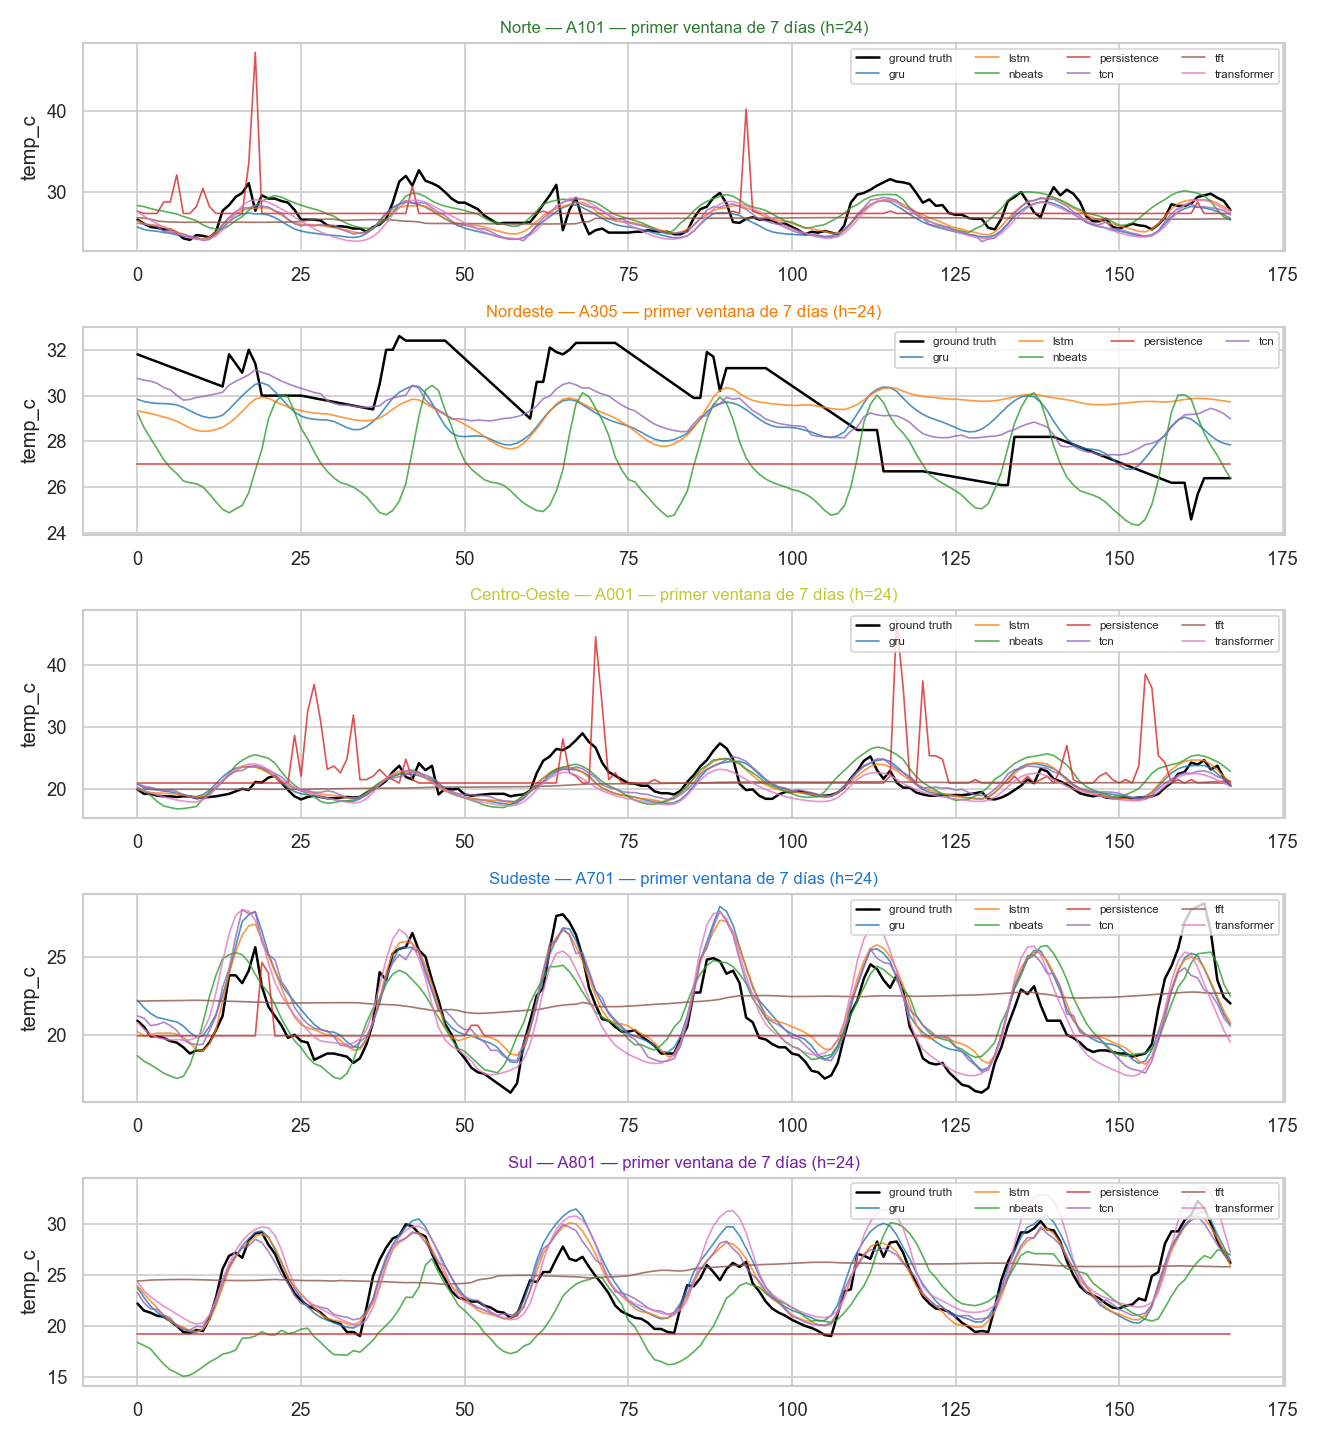

C:\Users\sergi\Proyecto-final-Deep-learning\results\figures\benchmark_final\07_pred_vs_truth_por_region.png


In [24]:
def plot_pred_vs_truth(window_hours: int = 168) -> Path | None:
    if PRED_LONG.empty: return None
    one_per_region = {}
    for region in all_regions():
        codes = stations_by_region(region)
        for c in codes:
            sub = PRED_LONG[PRED_LONG["station"] == c]
            if not sub.empty:
                one_per_region[region] = c
                break
    if not one_per_region: return None
    models_to_plot = sorted(PRED_LONG["model"].unique())
    fig, axes = plt.subplots(len(one_per_region), 1,
                             figsize=(11, 2.4 * len(one_per_region)),
                             sharex=False)
    if len(one_per_region) == 1: axes = [axes]
    for ax, (region, station) in zip(axes, one_per_region.items()):
        for m in models_to_plot:
            row = PRED_LONG.query("model==@m and station==@station and horizon==24")
            if row.empty: continue
            r = row.iloc[0]
            yt = r["y_true"][:window_hours]; yp = r["y_pred"][:window_hours]
            if m == models_to_plot[0]:
                ax.plot(yt, color="black", lw=1.5, label="ground truth")
            ax.plot(yp, lw=1, alpha=0.8, label=m)
        ax.set_title(f"{region} — {station} — primer ventana de 7 días (h=24)",
                     fontsize=10, color=region_color(region))
        ax.set_ylabel("temp_c")
        ax.legend(loc="upper right", fontsize=7, ncol=4)
    plt.tight_layout()
    out = FIG_DIR / "07_pred_vs_truth_por_region.png"
    fig.savefig(out, dpi=120); plt.close(fig)
    return out


show_saved_figure(plot_pred_vs_truth())

### 4.2 Errores sistemáticos — histograma + por hora del día + por mes

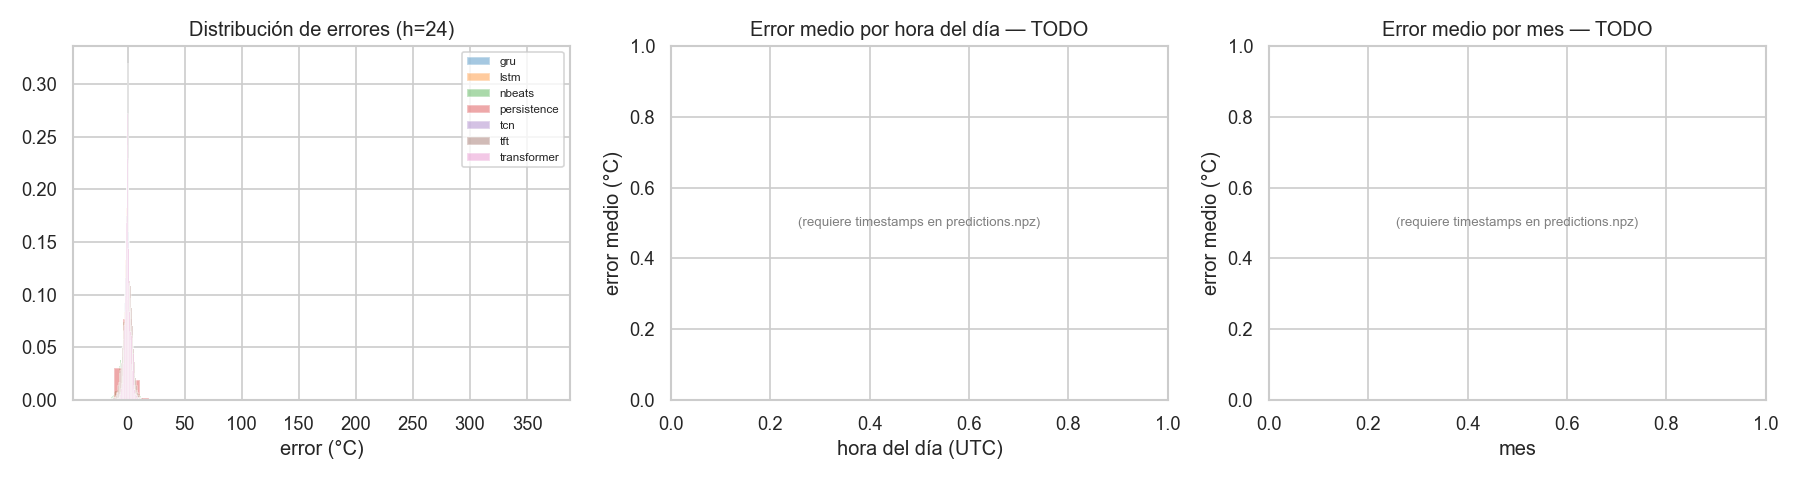

C:\Users\sergi\Proyecto-final-Deep-learning\results\figures\benchmark_final\08_error_distributions.png


In [25]:
def plot_error_distributions() -> Path | None:
    if PRED_LONG.empty: return None
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for m in sorted(PRED_LONG["model"].unique()):
        all_e = np.concatenate([(r["y_pred"] - r["y_true"]).ravel()
                                for _, r in PRED_LONG.query("model==@m and horizon==24").iterrows()])
        if len(all_e) == 0: continue
        axes[0].hist(all_e, bins=50, alpha=0.4, label=m, density=True)
    axes[0].set_title("Distribución de errores (h=24)")
    axes[0].set_xlabel("error (°C)"); axes[0].legend(fontsize=7)
    axes[1].set_title("Error medio por hora del día — TODO")
    axes[1].set_xlabel("hora del día (UTC)"); axes[1].set_ylabel("error medio (°C)")
    axes[1].text(0.5, 0.5, "(requiere timestamps en predictions.npz)",
                 ha="center", va="center", transform=axes[1].transAxes,
                 fontsize=8, color="gray")
    axes[2].set_title("Error medio por mes — TODO")
    axes[2].set_xlabel("mes"); axes[2].set_ylabel("error medio (°C)")
    axes[2].text(0.5, 0.5, "(requiere timestamps en predictions.npz)",
                 ha="center", va="center", transform=axes[2].transAxes,
                 fontsize=8, color="gray")
    plt.tight_layout()
    out = FIG_DIR / "08_error_distributions.png"
    fig.savefig(out, dpi=120); plt.close(fig)
    return out


show_saved_figure(plot_error_distributions())

### 4.3 Casos difíciles

In [26]:
def hardest_windows(top_k: int = 3) -> pd.DataFrame:
    if PRED_LONG.empty: return pd.DataFrame()
    rows = []
    for _, r in PRED_LONG.query("horizon==24").iterrows():
        e = r["y_pred"] - r["y_true"]
        if e.size == 0: continue
        worst_idx = np.argsort(np.abs(e))[-top_k:]
        for i in worst_idx:
            rows.append({"model": r["model"], "station": r["station"],
                         "region": r["region"], "seed": r["seed"],
                         "idx": int(i), "abs_err": float(abs(e[i]))})
    if not rows: return pd.DataFrame()
    df = pd.DataFrame(rows)
    return df.groupby(["station", "idx"]).agg(
        n_models=("model", "nunique"),
        mean_abs_err=("abs_err", "mean"),
    ).sort_values("mean_abs_err", ascending=False).head(20).reset_index()


HARDEST = hardest_windows()
if not HARDEST.empty:
    HARDEST.to_csv(TAB_DIR / "hardest_windows.csv", index=False)
HARDEST

,station,idx,n_models,mean_abs_err
0,A719,8138,1,367.374073
1,A701,404,1,262.784113
2,A309,3240,1,246.294422
3,A627,2450,1,234.482916
4,A002,2878,1,233.277344
5,A018,7630,1,221.191357
6,A801,933,1,191.412481
7,A210,8311,1,184.519291
8,A756,7915,1,182.031017
9,A815,547,1,170.172665


Si los **mismos índices** caen en los top-K de varios modelos
(`n_models` alto), el problema es del *dato*: probablemente coinciden con
eventos meteorológicos atípicos (frentes fríos, *heat waves*, faltantes de
radiación). Si los peores casos están **dispersos**, cada modelo falla en
patrones distintos — buena evidencia para *ensemble*.